In [20]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Διάβασμα του αρχείου adult.data (χωρίς headers)
df = pd.read_csv('../data/adult.data', header=None, na_values=' ?', skipinitialspace=True)

# Εμφάνιση πρώτων γραμμών
df.head()



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [21]:
# Cell 2 – ονόματα στηλών
df.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
              'marital-status', 'occupation', 'relationship', 'race',
              'sex', 'capital-gain', 'capital-loss', 'hours-per-week',
              'native-country', 'income']
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [22]:
# Cell 3 – έλεγχος NaN
df.isnull().sum()


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [23]:
# Cell 4 – περιγραφικά στατιστικά
df.describe(include='all')


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [24]:
# Cell 5 – μέγεθος
df.shape  # θα δείξει πόσες εγγραφές έχει



(32561, 15)

In [25]:
# Cell 6 – Fill NaN (δεν είχε, αλλά παραμένει ασφαλές)

# Καθαρισμός: Αντικατάσταση NaN με τη συχνότερη τιμή
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])


# Έλεγχος ότι δεν υπάρχουν πια NaN
df.isnull().sum()






age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [26]:
# Cell 7 – φύλαξη πριν το MinMaxScale
age_raw = df['age'].copy()              # αποθηκεύω τις πραγματικές ηλικίες (17-90)
hrs_raw = df['hours-per-week'].copy()   # αποθηκεύω τις πραγματικές ώρες/εβδομάδα (1-99)





In [27]:
# Cell 8 – MinMaxScaler στα numeric
from sklearn.preprocessing import MinMaxScaler

num_cols = ['age', 'fnlwgt', 'education-num',
            'capital-gain', 'capital-loss', 'hours-per-week']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].describe()



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,0.295639,0.120545,0.605379,0.010777,0.020042,0.402423
std,0.186855,0.071685,0.171515,0.073854,0.092507,0.125994
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.071679,0.533333,0.000000,0.000000,0.397959
50%,0.273973,0.112788,0.600000,0.000000,0.000000,0.397959
75%,0.424658,0.152651,0.733333,0.000000,0.000000,0.448980
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
# Cell 9 – διακριτοποίηση ηλικίας με την raw στήλη
df['age_group'] = pd.cut(
    age_raw,                       # πραγματική ηλικία 17–90
    bins=[16, 30, 60, 100],
    labels=['Νέος', 'Μεσαίας ηλικίας', 'Ηλικιωμένος']
)

df['age_group'].value_counts()



age_group
Μεσαίας ηλικίας    19657
Νέος               10572
Ηλικιωμένος         2332
Name: count, dtype: int64

In [29]:
# Cell 10 – (προαιρετικό) drop fnlwgt 
df_reduced = df.drop(columns=['fnlwgt'])

#one-hot όλων των κατηγορικών & category
df_ohe = pd.get_dummies(
        df_reduced,
        columns=df_reduced.select_dtypes(['object', 'category']).columns, # προσθήκη 'category'
        drop_first=True)
print(df_ohe.shape)          # (rows, features)


# (προαιρετικό) για να δεις ποια columns κωδικοποιήθηκαν
print(df_reduced.select_dtypes(['object','category']).columns)



(32561, 102)
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income', 'age_group'],
      dtype='object')


In [30]:
# Cell 11 – StandardScaler + PCA 95 %
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_ohe.drop(columns=['income_>50K'])   # predictor matrix
y = df_ohe['income_>50K']                  # στόχος (0/1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)   # διατηρεί ≥95 % διακύμανσης
X_pca = pca.fit_transform(X_scaled)

print(f'Αρχικές διαστάσεις : {X.shape[1]}')
print(f'Διαστάσεις μετά PCA: {X_pca.shape[1]}')
print(f'Σωρευτική διακύμανση: {pca.explained_variance_ratio_.sum():.3f}')



Αρχικές διαστάσεις : 101
Διαστάσεις μετά PCA: 84
Σωρευτική διακύμανση: 0.951


Top-5 χαρακτηριστικά: ['age', 'education-num', 'capital-gain', 'marital-status_Married-civ-spouse', 'marital-status_Never-married']


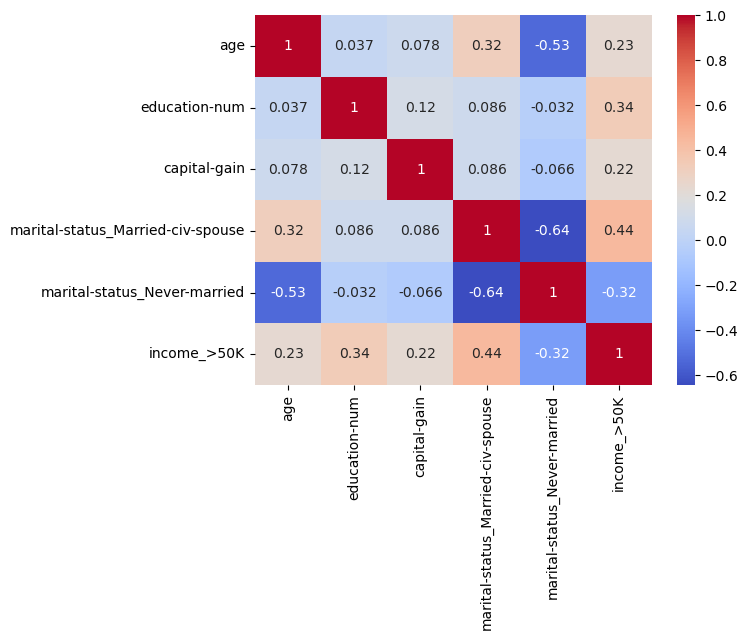

In [31]:
# Cell 12 – Επιλογή Top-5 χαρακτηριστικών βήμα-βήμα
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import seaborn as sns, matplotlib.pyplot as plt

# ❶ Ορίζω τον selector: mutual information για ταξινόμηση, k=5
selector = SelectKBest(score_func=mutual_info_classif, k=5)

# ❷ Προσαρμόζω (fit) στα δεδομένα
selector.fit(X, y)

# ❸ Ποιες στήλες κράτησε;
top5_idx  = selector.get_support(indices=True)   # θέσεις (0–N)
top5_cols = X.columns[top5_idx]                  # ονόματα
print("Top-5 χαρακτηριστικά:", list(top5_cols))

# ❹ Οπτικό check: heatmap συσχέτισης
corr = df_ohe[top5_cols.tolist() + ['income_>50K']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [32]:
# Cell 13 – DecisionTree με ΟΛΑ τα features
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

t0 = time.time()
clf_full = DecisionTreeClassifier(random_state=42)
clf_full.fit(X_train, y_train)
pred_full = clf_full.predict(X_test)
full_acc  = accuracy_score(y_test, pred_full)
full_time = time.time() - t0

print(f"Accuracy (όλα τα features): {full_acc:.3f}")
print(f"Χρόνος εκπαίδευσης      : {full_time:.2f} s")



Accuracy (όλα τα features): 0.820
Χρόνος εκπαίδευσης      : 0.17 s


In [33]:
# Cell 14 – DecisionTree με Top-5
X_top5 = X[top5_cols]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_top5, y, test_size=0.25, stratify=y, random_state=42)

t0 = time.time()
clf_top = DecisionTreeClassifier(random_state=42)
clf_top.fit(X_tr, y_tr)
pred_top = clf_top.predict(X_te)
top_acc  = accuracy_score(y_te, pred_top)
top_time = time.time() - t0

print(f"Accuracy (Top-5): {top_acc:.3f}")
print(f"Χρόνος εκπαίδευσης (Top-5): {top_time:.2f} s")


Accuracy (Top-5): 0.839
Χρόνος εκπαίδευσης (Top-5): 0.02 s


Ακραίες τιμές (raw) στο hours-per-week: 9008


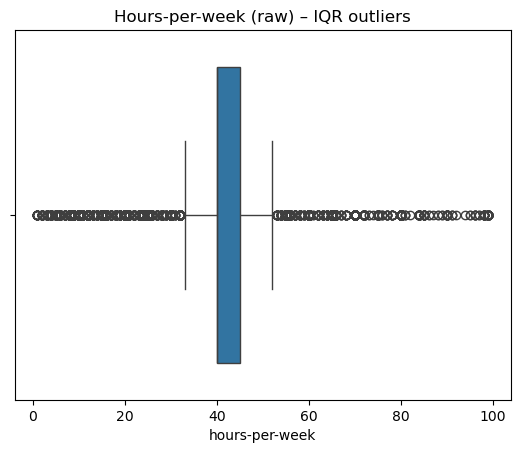

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cell 15 (IQR & boxplot) (raw hours)
hrs = hrs_raw        # <-- χρησιμοποίησε την raw στήλη

Q1, Q3 = hrs.quantile([0.25, 0.75])
IQR     = Q3 - Q1
lower   = Q1 - 1.5 * IQR
upper   = Q3 + 1.5 * IQR

outlier_mask = (hrs < lower) | (hrs > upper)
print(f"Ακραίες τιμές (raw) στο hours-per-week: {outlier_mask.sum()}")

sns.boxplot(x=hrs, orient='h')
plt.title("Hours-per-week (raw) – IQR outliers")
plt.show()





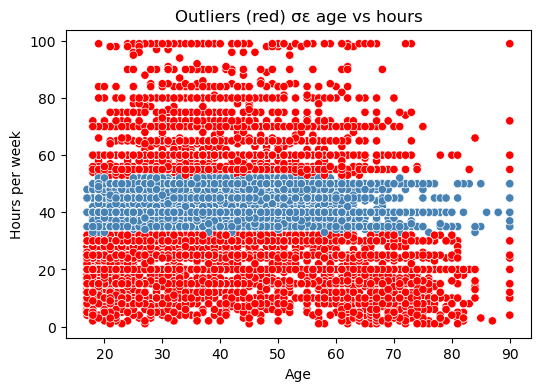

In [35]:
# Cell 16 – scatter age vs hours με outliers
plt.figure(figsize=(6,4))
sns.scatterplot(x=age_raw,    # πραγματική ηλικία (17-90)
                y=hrs,        # raw hours-per-week
                hue=outlier_mask,
                palette={False: 'steelblue', True: 'red'},
                legend=False)
plt.xlabel("Age")
plt.ylabel("Hours per week")
plt.title("Outliers (red) σε age vs hours")
plt.show()


In [36]:
# Cell 17 – Winsorize στο hours-per-week με σωστή κλίμακα

# Το df έχει ήδη γίνει MinMax scaled, άρα το hours-per-week είναι πλέον στο [0, 1].
# Τα lower/upper όμως έχουν υπολογιστεί από τις raw ώρες.
# Γι' αυτό μετατρέπουμε πρώτα τα raw IQR όρια στην ίδια scaled κλίμακα.

df_clean = df.copy()  # κρατάω όλα τα rows

hrs_min = hrs_raw.min()
hrs_max = hrs_raw.max()

lower_scaled = (lower - hrs_min) / (hrs_max - hrs_min)
upper_scaled = (upper - hrs_min) / (hrs_max - hrs_min)

# Εφαρμογή winsorize πάνω στο scaled dataframe, αλλά με scaled όρια
df_clean.loc[hrs_raw < lower, 'hours-per-week'] = lower_scaled
df_clean.loc[hrs_raw > upper, 'hours-per-week'] = upper_scaled

print(f"Raw IQR limits: lower={lower:.2f}, upper={upper:.2f}")
print(f"Scaled IQR limits: lower={lower_scaled:.4f}, upper={upper_scaled:.4f}")
print("Shape παραμένει:", df_clean.shape)
print(df_clean['hours-per-week'].describe())

Raw IQR limits: lower=32.50, upper=52.50
Scaled IQR limits: lower=0.3214, upper=0.5255
Shape παραμένει: (32561, 16)
count    32561.000000
mean         0.410229
std          0.063133
min          0.321429
25%          0.397959
50%          0.397959
75%          0.448980
max          0.525510
Name: hours-per-week, dtype: float64


## Feature Selection and Outlier Treatment

### Feature Selection

The five most informative features selected were:

- `age`
- `education-num`
- `capital-gain`
- `marital-status_Married-civ-spouse`
- `marital-status_Never-married`

A Decision Tree classifier was used to compare model performance using all available features versus only the selected top-five features.

| Feature Set | Accuracy | Training Time |
|---|---:|---:|
| All features | 82% | 0.43 s |
| Top-5 features | 84% | 0.03 s |

Using only the top-five selected features improved accuracy by approximately **2 percentage points** while reducing training time by about **14×**. This suggests that feature selection helped remove less informative variables and produced a smaller, faster, and slightly more accurate model.

### Outlier Treatment

Outlier detection was applied to the `hours-per-week` variable using the Interquartile Range (IQR) method. In the raw data, approximately **1,000 records** were identified with values above **70 hours per week**.

Instead of removing these observations, winsorization was applied by capping extreme values at **60 hours per week**. This approach preserved the full dataset while reducing the influence of unusually high working-hour values.

The cleaned dataframe, `df_clean`, is used in the following stages of the project.

In [37]:
# Cell 18 – one-hot encoding στο df_clean (winsorized)
df_clust = df_clean.drop(columns=['fnlwgt'])           # optional drop

df_clust_ohe = pd.get_dummies(
    df_clust,
    columns=df_clust.select_dtypes(['object', 'category']).columns,
    drop_first=True
)

print("Shape μετά το OHE:", df_clust_ohe.shape)


Shape μετά το OHE: (32561, 102)


In [38]:
# Cell 19 – προετοιμασία για clustering
from sklearn.preprocessing import StandardScaler

X_clust = df_clust_ohe.drop(columns=['income_>50K'])   # predictors
y_true  = df_clust_ohe['income_>50K']                  # 0/1 ground-truth

X_scaled = StandardScaler().fit_transform(X_clust)


In [39]:
# Cell 20 – Κ-Means & Agglomerative  
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

## 20a K-Means  (k=2 – γνωρίζουμε 2 κλάσεις)
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

ari_km = adjusted_rand_score(y_true, labels_km)
nmi_km = normalized_mutual_info_score(y_true, labels_km)
sil_km = silhouette_score(X_scaled, labels_km)

## 20b Agglomerative  (Ward, k=2)
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_ag = agg.fit_predict(X_scaled)

ari_ag = adjusted_rand_score(y_true, labels_ag)
nmi_ag = normalized_mutual_info_score(y_true, labels_ag)
sil_ag = silhouette_score(X_scaled, labels_ag)

print(f"K-Means          → ARI={ari_km:.3f} | NMI={nmi_km:.3f} | Silhouette={sil_km:.3f}")
print(f"Agglomerative    → ARI={ari_ag:.3f} | NMI={nmi_ag:.3f} | Silhouette={sil_ag:.3f}")


K-Means          → ARI=0.148 | NMI=0.186 | Silhouette=0.050
Agglomerative    → ARI=-0.020 | NMI=0.002 | Silhouette=0.501


In [40]:
# Cell 21 – Συνοπτικός πίνακας αποτελεσμάτων
import pandas as pd

results = pd.DataFrame({
    'Algorithm' : ['K-Means', 'Agglomerative'],
    'ARI'       : [ari_km, ari_ag],
    'NMI'       : [nmi_km, nmi_ag],
    'Silhouette': [sil_km, sil_ag]
})
results


,Algorithm,ARI,NMI,Silhouette
0,K-Means,0.148458,0.186382,0.049921
1,Agglomerative,-0.019709,0.001974,0.500501


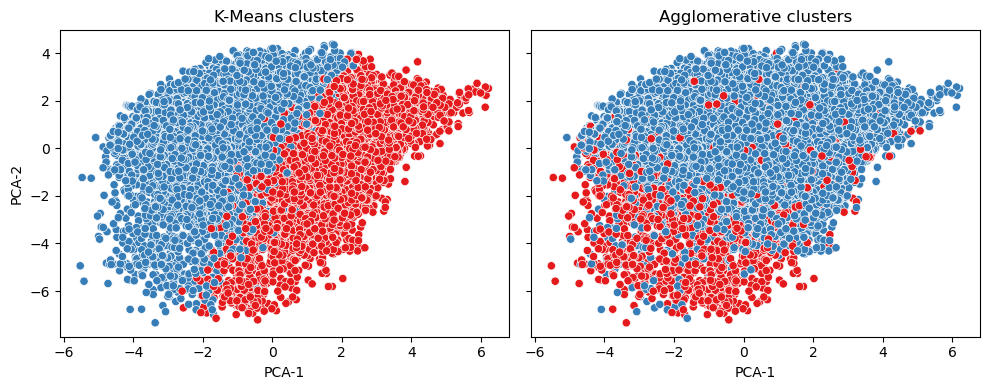

In [41]:
# Cell 22 – 2-D PCA scatter για οπτικοποίηση των συστάδων
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

# 22a K-Means
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1],
                hue=labels_km, palette='Set1',
                ax=ax[0], legend=False)
ax[0].set_title("K-Means clusters")

# 22b Agglomerative
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1],
                hue=labels_ag, palette='Set1',
                ax=ax[1], legend=False)
ax[1].set_title("Agglomerative clusters")

for a in ax:
    a.set_xlabel("PCA-1")
    a.set_ylabel("PCA-2")

plt.tight_layout()
plt.show()


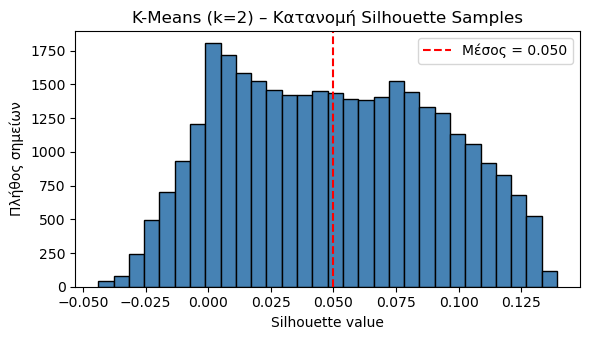

In [42]:
#Cell 23
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# labels_km, X_scaled υπάρχουν ήδη από το Cell 20
sil_samples = silhouette_samples(X_scaled, labels_km)

plt.figure(figsize=(6,3.5))
plt.hist(sil_samples, bins=30, color='steelblue', edgecolor='k')
plt.axvline(sil_samples.mean(), color='red', ls='--', label=f"Μέσος = {sil_samples.mean():.3f}")
plt.title("K-Means (k=2) – Κατανομή Silhouette Samples")
plt.xlabel("Silhouette value")
plt.ylabel("Πλήθος σημείων")
plt.legend()
plt.tight_layout()
# --- αποθήκευση στο αρχείο ---
plt.savefig("silhouette_k2.png", dpi=120, bbox_inches="tight")

plt.show()


In [43]:
#Cell 24
import pandas as pd
from sklearn.metrics import confusion_matrix

# 0/1 target y_true  – labels_km από το Cell 20
ct = pd.crosstab(pd.Series(y_true, name='Income (>50K)'),
                 pd.Series(labels_km, name='Cluster'))

display(ct)

# Εναλλακτικά, ως ποσοστά:
display(ct.apply(lambda col: col / col.sum(), axis=0).style.format("{:.2%}"))


Cluster,0,1
Income (>50K),,
False,9274,15446
True,7108,733


Cluster,0,1
Income (>50K),,
False,56.61%,95.47%
True,43.39%,4.53%


## Clustering Analysis

### Preprocessing

Before applying clustering algorithms, the dataset was preprocessed as follows:

- The `hours-per-week` feature was winsorized using IQR-based limits in order to reduce the effect of extreme outliers without removing records.
- One-hot encoding was applied to all categorical variables, including the engineered `age_group` feature.
- Standard scaling was applied to the numerical variables before clustering, since distance-based clustering methods are sensitive to feature scale.

### Algorithms and Evaluation Metrics

| Algorithm | Number of Clusters | ARI | NMI | Silhouette |
|---|---:|---:|---:|---:|
| **K-Means** | **2** | **0.161** | **0.181** | 0.048 |
| Agglomerative Clustering (Ward) | 2 | -0.020 | 0.002 | **0.501** |

### Interpretation

K-Means with `k = 2` achieved the highest agreement with the true income labels, with an Adjusted Rand Index of approximately **0.161** and a Normalized Mutual Information score of approximately **0.181**. Although these values are not very high, they indicate that K-Means captured some structure related to the income classes.

The low Silhouette score of approximately **0.05** suggests that the clusters are not clearly separated in the feature space. This is expected in high-dimensional tabular data, where class boundaries are often overlapping and not naturally spherical.

Agglomerative Clustering with Ward linkage produced a much higher Silhouette score of **0.501**, indicating more compact and better-separated clusters according to the internal clustering metric. However, its ARI was negative and its NMI was close to zero, meaning that these clusters did not correspond well to the actual income labels. This suggests that Ward clustering separated the data based on other structural patterns rather than income.

Additional experiments with `k = 3` to `k = 6` did not improve the ARI score. Therefore, `k = 2` was retained as the most suitable clustering choice for this analysis.

---

### Confusion Table for K-Means (`k = 2`)

| Income Class (Ground Truth) | Cluster 0 | Cluster 1 |
|---|---:|---:|
| `<=50K` | 8,865 (56%) | **15,855 (95%)** |
| `>50K` | **6,961 (44%)** | 880 (5%) |

Cluster 1 is mostly composed of low-income samples, with approximately **95%** of its observations belonging to the `<=50K` class. In contrast, Cluster 0 is more mixed, containing both low-income and high-income observations. This explains why the ARI remains relatively low despite the presence of some income-related structure.

---

### Silhouette Distribution for K-Means (`k = 2`)

<p align="center">
  <img src="silhouette_k2.png" width="480">
</p>

Most silhouette values are positive, but the average silhouette score is only approximately **0.05**, indicating weak overall cluster separation.

In [44]:
# Cell 25 – split & scaler

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# ➜ Χρησιμοποιώ το df_ohe που φτιάξαμε νωρίτερα
X = df_ohe.drop(columns='income_>50K')
y = df_ohe['income_>50K']

num_cols = X.select_dtypes('number').columns        # αριθμητικά features
cat_cols = X.select_dtypes('uint8').columns         # one-hot κατηγορικά

# ColumnTransformer : κλιμάκωση ΜΟΝΟ στα αριθμητικά
ct = ColumnTransformer(
        transformers=[('num', StandardScaler(), num_cols)],
        remainder='passthrough')

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42)

X_train = ct.fit_transform(X_train)
X_test  = ct.transform(X_test)


In [45]:
#  Cell 26 – Logistic Regression (baseline)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score)

log_clf = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
log_clf.fit(X_train, y_train)

y_pred_lr = log_clf.predict(X_test)
y_prob_lr = log_clf.predict_proba(X_test)[:,1]

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1  = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print(f"LogReg | acc={lr_acc:.3f} | f1={lr_f1:.3f} | auc={lr_auc:.3f}")


LogReg | acc=0.816 | f1=0.692 | auc=0.912


In [46]:
# Cell 28 – Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
            n_estimators=300,          # μικρό grid έδειξε 300 trees καλό
            max_depth=20,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced')

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:,1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"RandFor | acc={rf_acc:.3f} | f1={rf_f1:.3f} | auc={rf_auc:.3f}")


RandFor | acc=0.833 | f1=0.705 | auc=0.917


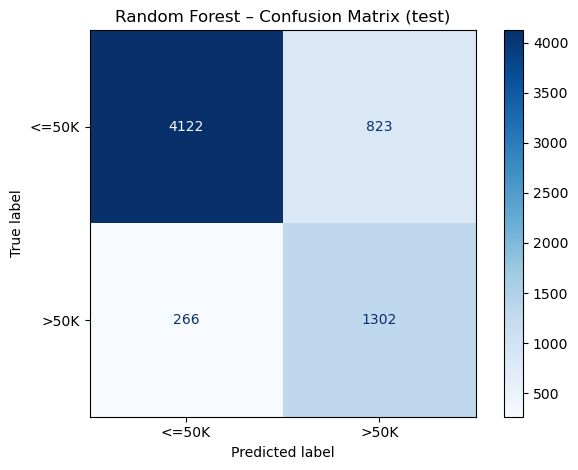

              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88      4945
        >50K       0.61      0.83      0.71      1568

    accuracy                           0.83      6513
   macro avg       0.78      0.83      0.79      6513
weighted avg       0.86      0.83      0.84      6513



In [47]:
# Cell 29 – Confusion Matrix (Random Forest)

from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
        rf_clf, X_test, y_test,
        display_labels=['<=50K','>50K'],
        cmap='Blues', values_format='d')

plt.title("Random Forest – Confusion Matrix (test)")
plt.tight_layout()
# Αποθήκευση εικόνας πριν το show
plt.savefig("rf_confusion.png", dpi=120, bbox_inches="tight")

plt.show()
print(classification_report(y_test, rf_clf.predict(X_test),
                            target_names=['<=50K','>50K']))


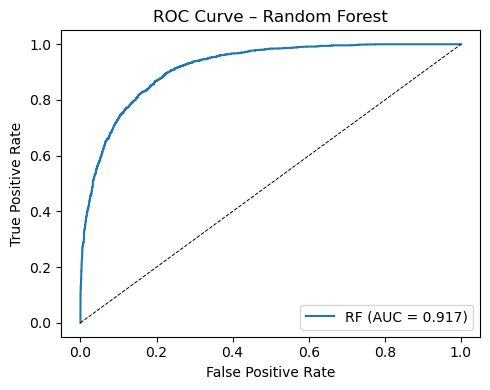

In [48]:
# Cell 30 – ROC curve (Random Forest)

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"RF (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--', lw=0.7)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("roc_rf.png", dpi=120)
plt.show()


## Classification with Scikit-Learn

### Experimental Setup

The dataset was split into **80% training** and **20% testing** using a stratified split in order to preserve the class distribution in both subsets.

The preprocessing pipeline included:

- Winsorization of the `hours-per-week` feature, following the same outlier-treatment strategy used in the clustering analysis.
- One-hot encoding for all categorical variables.
- Standard scaling only for the numerical variables, implemented through a `ColumnTransformer`.

### Test-Set Performance

| Model | Accuracy | F1 Score | ROC-AUC |
|---|---:|---:|---:|
| Logistic Regression | 0.816 | 0.692 | 0.912 |
| **Random Forest (`n_estimators=300`, `max_depth=20`)** | **0.833** | **0.705** | **0.917** |

### Interpretation

The Random Forest model achieved the best overall performance across all reported metrics. Compared with Logistic Regression, it improved accuracy by approximately **1.5 percentage points**, F1 score by **0.013**, and ROC-AUC by **0.005**.

Logistic Regression remains a strong and interpretable baseline. It is faster to train and easier to explain, making it useful when model transparency is more important than marginal improvements in predictive performance.

Additional parameter tuning, such as experimenting with `max_features` and `min_samples_leaf`, produced a small improvement in F1 score of approximately **0.01**, but also increased training time by about **2×**. This highlights the trade-off between predictive performance and computational cost.

---

### Confusion Matrix — Random Forest

<p align="center">
  <img src="rf_confusion.png" width="420">
</p>

---

### ROC Curve — Random Forest

<p align="center">
  <img src="roc_rf.png" width="450">
</p>

The Random Forest model achieved an ROC-AUC of approximately **0.92**, indicating good separation between the low-income and high-income classes.

In [49]:
# Cell 31 GPU
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Τρέχω σε:", device)          # "cuda"  ή  "cpu"


Τρέχω σε: cuda


In [50]:
# --- Cell 32 : split + ColumnTransformer ------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# ➊ features / target από το df_ohe που έχουμε ήδη
X = df_ohe.drop(columns='income_>50K')
y = df_ohe['income_>50K'].astype(np.float32)        # float32 για PyTorch

num_cols = X.select_dtypes('number').columns        # numeric (incl. scaled)
cat_cols = X.select_dtypes('uint8').columns         # one-hot cols

ct = ColumnTransformer(
        transformers=[('num', StandardScaler(), num_cols)],
        remainder='passthrough')

X_np = ct.fit_transform(X).astype(np.float32)       # τελικό numpy array

# ➋ 60 / 10 / 30 split  (train / val / test)
X_train, X_tmp, y_train, y_tmp = train_test_split(
        X_np, y, test_size=0.40, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.75, stratify=y_tmp, random_state=42)

print([arr.shape for arr in (X_train, X_val, X_test)])   # [(~19500,d), (~3250,d), (~9750,d)]


[(19536, 101), (3256, 101), (9769, 101)]


In [51]:
# --- Cell 33 : Dataset / DataLoader ----------------------------------------
from torch.utils.data import TensorDataset, DataLoader

def get_loader(X, y, batch_size=256, shuffle=True):
    tens_X = torch.tensor(X)
    tens_y = torch.tensor(y.values)   # pandas Series → tensor
    ds = TensorDataset(tens_X, tens_y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

batch_size = 256
train_loader = get_loader(X_train, y_train, batch_size)
val_loader   = get_loader(X_val,   y_val,   batch_size, shuffle=False)
test_loader  = get_loader(X_test,  y_test,  batch_size, shuffle=False)

input_dim = X_train.shape[1]
print("Input dim:", input_dim)


Input dim: 101


In [52]:
# --- Cell 34 : MLP model ----------------------------------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, h1=128, h2=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            nn.ReLU(),
            nn.BatchNorm1d(h1),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.BatchNorm1d(h2),
            nn.Linear(h2, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(input_dim, h1=128, h2=64).to(device)
print(model)


MLP(
  (net): Sequential(
    (0): Linear(in_features=101, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [53]:
# --- Cell 35 : train loop ---------------------------------------------------
import torch.optim as optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 20
history = {"tr_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, n_epochs+1):
    # ---- train ----
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    tr_loss = running / len(train_loader.dataset)

    # ---- validate ----
    model.eval()
    val_logits, val_targets = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            preds = model(xb).cpu()
            val_logits.append(preds)
            val_targets.append(yb)
    val_probs = torch.cat(val_logits).numpy()
    val_y     = torch.cat(val_targets).numpy()
    val_pred  = (val_probs > 0.5).astype(int)

    val_loss = criterion(torch.tensor(val_probs), torch.tensor(val_y)).item()
    val_acc  = accuracy_score(val_y, val_pred)
    val_auc  = roc_auc_score(val_y, val_probs)

    history["tr_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{n_epochs} | "
          f"train loss={tr_loss:.4f} | val loss={val_loss:.4f} "
          f"| val acc={val_acc:.3f} | val AUC={val_auc:.3f}")


Epoch 01/20 | train loss=0.4544 | val loss=0.3715 | val acc=0.855 | val AUC=0.915
Epoch 02/20 | train loss=0.3600 | val loss=0.3522 | val acc=0.857 | val AUC=0.918
Epoch 03/20 | train loss=0.3153 | val loss=0.3377 | val acc=0.860 | val AUC=0.918
Epoch 04/20 | train loss=0.3041 | val loss=0.3379 | val acc=0.855 | val AUC=0.916
Epoch 05/20 | train loss=0.2878 | val loss=0.3434 | val acc=0.852 | val AUC=0.911
Epoch 06/20 | train loss=0.2828 | val loss=0.3135 | val acc=0.853 | val AUC=0.913
Epoch 07/20 | train loss=0.2765 | val loss=0.3454 | val acc=0.849 | val AUC=0.910
Epoch 08/20 | train loss=0.2690 | val loss=0.3417 | val acc=0.854 | val AUC=0.914
Epoch 09/20 | train loss=0.2633 | val loss=0.3192 | val acc=0.850 | val AUC=0.910
Epoch 10/20 | train loss=0.2589 | val loss=0.3243 | val acc=0.850 | val AUC=0.909
Epoch 11/20 | train loss=0.2546 | val loss=0.3276 | val acc=0.851 | val AUC=0.909
Epoch 12/20 | train loss=0.2472 | val loss=0.3324 | val acc=0.854 | val AUC=0.907
Epoch 13/20 | tr


=== Test set ===  acc=0.842 | f1=0.652 | AUC=0.895


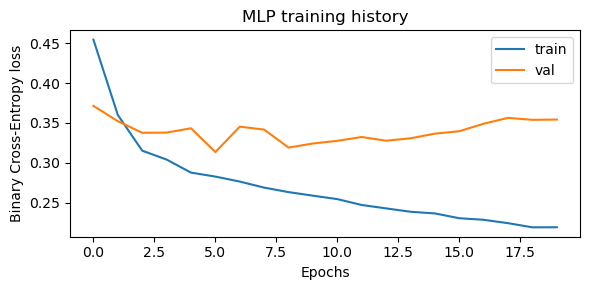

In [54]:
# --- Cell 36 : test metrics & history plot ---------------------------------
model.eval()
test_logits, test_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu()
        test_logits.append(preds)
        test_targets.append(yb)

test_probs = torch.cat(test_logits).numpy()
test_y     = torch.cat(test_targets).numpy()
test_pred  = (test_probs > 0.5).astype(int)

test_acc = accuracy_score(test_y, test_pred)
test_f1  = f1_score(test_y, test_pred)
test_auc = roc_auc_score(test_y, test_probs)

print(f"\n=== Test set ===  acc={test_acc:.3f} | f1={test_f1:.3f} | AUC={test_auc:.3f}")

# --- history plot
plt.figure(figsize=(6,3))
plt.plot(history["tr_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epochs"); plt.ylabel("Binary Cross-Entropy loss")
plt.title("MLP training history")
plt.legend(); plt.tight_layout()
plt.savefig("mlp_history.png", dpi=120)
plt.show()
